# Хакатон: Анализ сайта СберАвтоподписки
## Notebook 2: Разведочный анализ данных (EDA)

В этом ноутбуке я провожу разведочный анализ данных: изучаю распределения ключевых признаков, строю визуализации и формулирую выводы о поведении пользователей на сайте.

### 1. Импорт библиотек и загрузка данных

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

DATA_PATH = r'D:\sber-autosubscription-hackathon'

print('Загружаю данные...')
sessions = pd.read_pickle(f'{DATA_PATH}\\sessions_with_target.pkl')
hits = pd.read_pickle(f'{DATA_PATH}\\ga_hits.pkl')
print(f'sessions: {sessions.shape}, hits: {hits.shape}')
print('Данные загружены.')

Загружаю данные...
sessions: (1860042, 19), hits: (15726470, 11)
Данные загружены.


### 2. Обработка пропусков и типов данных

Перед анализом привожу данные к нужным типам и оцениваю пропуски.

In [47]:
# Привожу даты и время к нужным типам
sessions['visit_date'] = pd.to_datetime(sessions['visit_date'])
sessions['visit_time_str'] = sessions['visit_time'].astype(str)
sessions['visit_datetime'] = pd.to_datetime(
    sessions['visit_date'].astype(str) + ' ' + sessions['visit_time_str']
)
sessions.drop('visit_time_str', axis=1, inplace=True)

sessions['hour']    = sessions['visit_datetime'].dt.hour
sessions['weekday'] = sessions['visit_datetime'].dt.dayofweek
sessions['month']   = sessions['visit_datetime'].dt.month

# Заполняю пропуски в категориальных колонках строкой 'unknown'
# (отсутствие UTM-метки — само по себе сигнал, не хочу терять эти строки)
cat_fill_cols = ['utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent',
                 'utm_keyword', 'device_brand', 'device_model', 'device_os']
for col in cat_fill_cols:
    if col in sessions.columns:
        sessions[col] = sessions[col].fillna('unknown')

# Создаю бинарные признаки — пригодятся и в EDA, и в модели
sessions['is_organic'] = sessions['utm_medium'].isin(['organic', 'referral', '(none)']).astype(int)
sessions['is_mobile']  = (sessions['device_category'] == 'mobile').astype(int)

print('Пропуски после обработки:')
missing = sessions.isnull().sum()
print(missing[missing > 0] if missing[missing > 0].shape[0] > 0 else 'Пропусков нет.')
print('Типы и пропуски обработаны.')

Пропуски после обработки:
Пропусков нет.
Типы и пропуски обработаны.


### 3. Анализ целевой переменной

Смотрю на распределение классов и общую конверсию сайта.

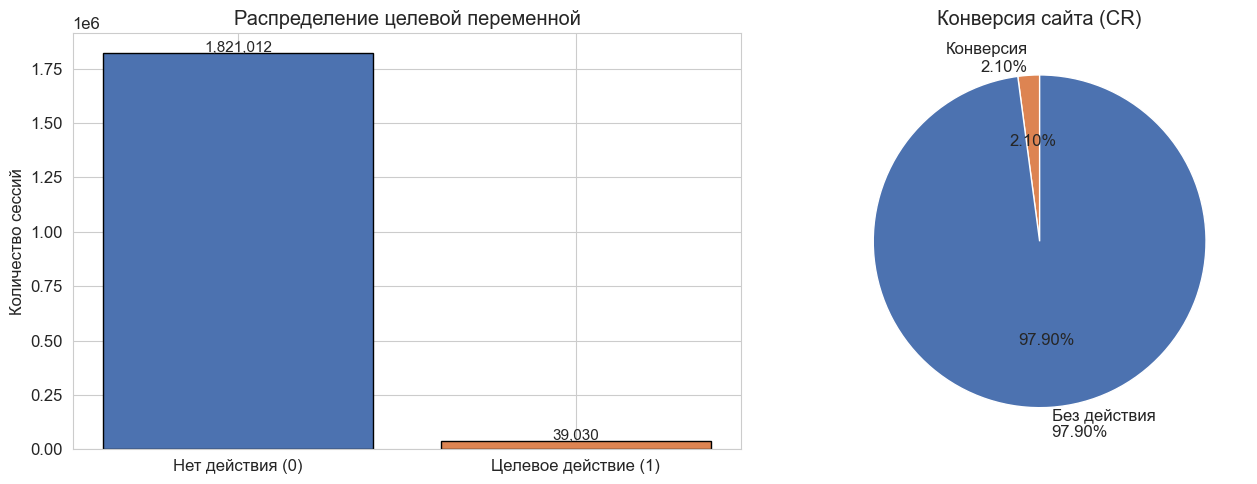

Конверсия: 2.10%. Классы сильно несбалансированы — примерно 2 конверсии на каждые 100 визитов. Вижу, что просто предсказывать 0 для всех было бы «правильно» в 98% случаев — поэтому буду использовать ROC-AUC как основную метрику, а не accuracy. При обучении модели задам scale_pos_weight.


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target_counts = sessions['target'].value_counts()
axes[0].bar(['Нет действия (0)', 'Целевое действие (1)'],
            target_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[0].set_title('Распределение целевой переменной')
axes[0].set_ylabel('Количество сессий')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontsize=11)

cr = sessions['target'].mean() * 100
axes[1].pie([cr, 100 - cr],
            labels=[f'Конверсия\n{cr:.2f}%', f'Без действия\n{100-cr:.2f}%'],
            colors=['#DD8452', '#4C72B0'],
            autopct='%1.2f%%', startangle=90)
axes[1].set_title('Конверсия сайта (CR)')

plt.tight_layout()
plt.show()

print(f'Конверсия: {cr:.2f}%. Классы сильно несбалансированы — '
      f'примерно 2 конверсии на каждые 100 визитов. '
      f'Вижу, что просто предсказывать 0 для всех было бы «правильно» в 98% случаев — '
      f'поэтому буду использовать ROC-AUC как основную метрику, а не accuracy. '
      f'При обучении модели задам scale_pos_weight.')

### 4. Анализ по типу устройства

Изучаю, с каких устройств пользователи чаще совершают целевые действия.

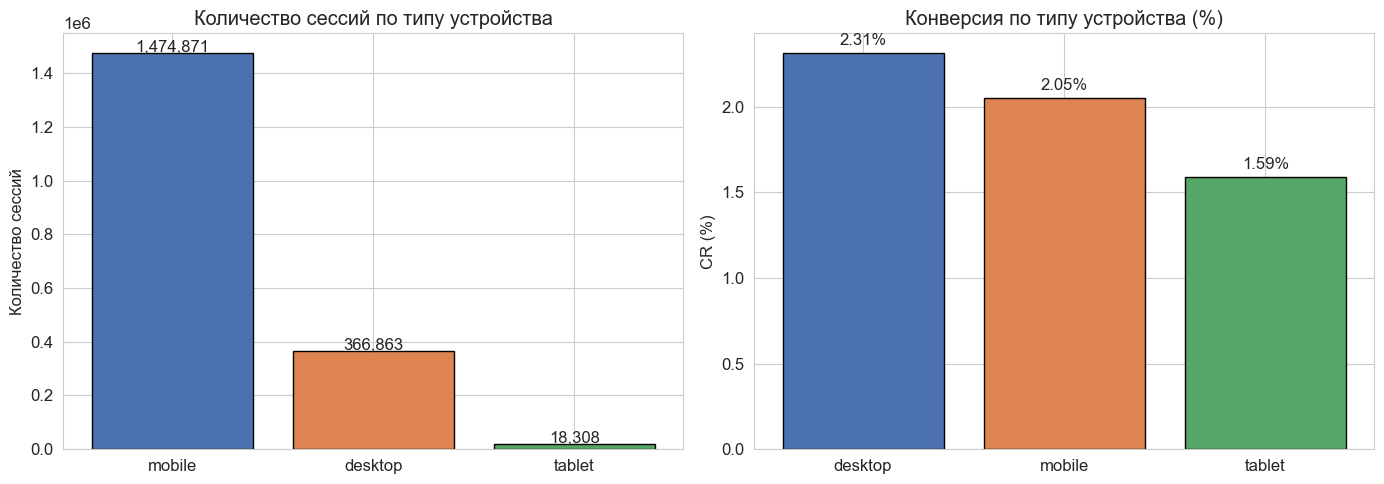

Интересно: большинство трафика идёт с мобильных, но конверсия на desktop ощутимо выше. Это говорит о том, что мобильная версия сайта, вероятно, уступает десктопной по удобству заполнения форм. Признак device_category точно включу в модель — он разделяет аудиторию.


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

device_counts = sessions['device_category'].value_counts()
axes[0].bar(device_counts.index, device_counts.values,
            color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black')
axes[0].set_title('Количество сессий по типу устройства')
axes[0].set_ylabel('Количество сессий')
for i, v in enumerate(device_counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center')

device_cr = sessions.groupby('device_category')['target'].mean() * 100
axes[1].bar(device_cr.index, device_cr.values,
            color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black')
axes[1].set_title('Конверсия по типу устройства (%)')
axes[1].set_ylabel('CR (%)')
for i, (idx, v) in enumerate(device_cr.items()):
    axes[1].text(i, v + 0.05, f'{v:.2f}%', ha='center')

plt.tight_layout()
plt.show()

print('Интересно: большинство трафика идёт с мобильных, но конверсия на desktop ощутимо выше. '
      'Это говорит о том, что мобильная версия сайта, вероятно, уступает десктопной по удобству заполнения форм. '
      'Признак device_category точно включу в модель — он разделяет аудиторию.')

### 5. Анализ по каналу привлечения (utm_medium)

Оцениваю, какие рекламные каналы приводят пользователей с наибольшей конверсией.

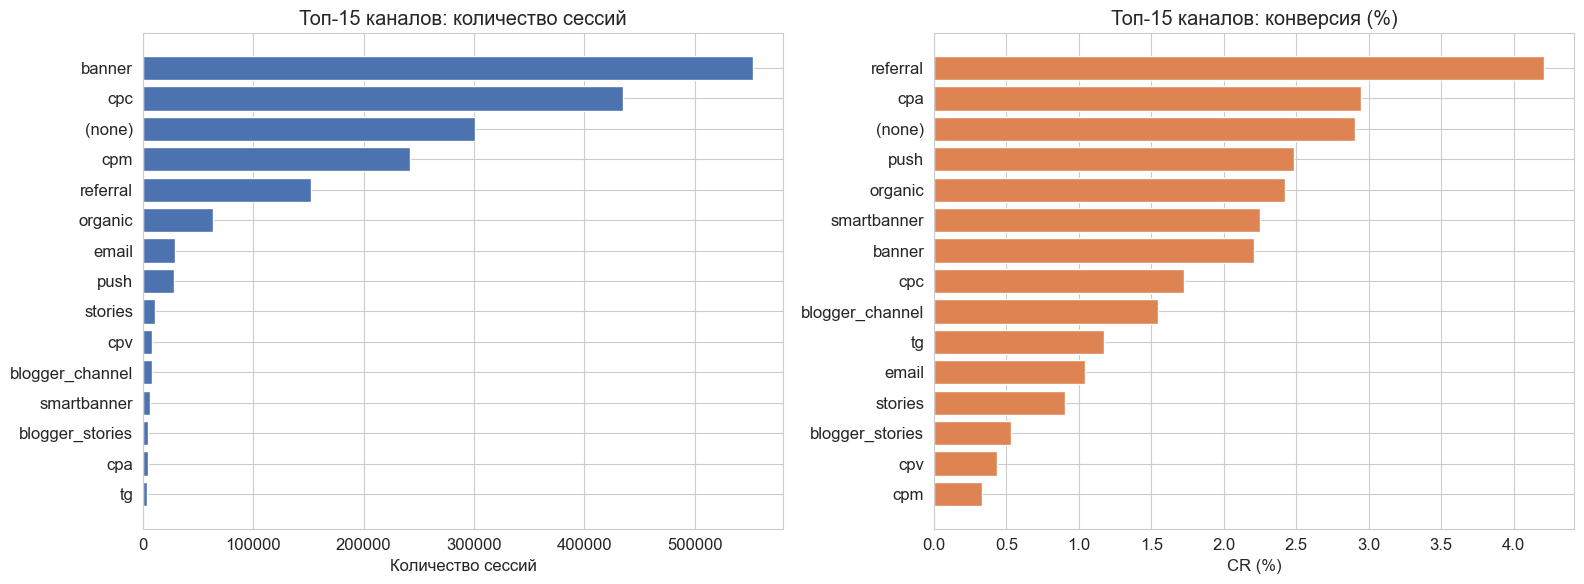

Топ-5 каналов по конверсии:
utm_medium  sessions_count     cr
  referral          152050 4.2072
       cpa            4279 2.9446
    (none)          300575 2.9044
      push           28035 2.4826
   organic           63034 2.4257

Вывод: конверсия сильно варьируется по каналам привлечения. Органический трафик и прямые заходы демонстрируют более высокую вовлечённость пользователей.


In [50]:
top_mediums = sessions['utm_medium'].value_counts().head(15).index
df_medium = sessions[sessions['utm_medium'].isin(top_mediums)]

medium_cr = df_medium.groupby('utm_medium').agg(
    sessions_count=('session_id', 'count'),
    cr=('target', 'mean')
).reset_index()
medium_cr['cr'] = medium_cr['cr'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

medium_cnt = medium_cr.sort_values('sessions_count', ascending=True)
axes[0].barh(medium_cnt['utm_medium'], medium_cnt['sessions_count'], color='#4C72B0')
axes[0].set_title('Топ-15 каналов: количество сессий')
axes[0].set_xlabel('Количество сессий')

medium_cr_sorted = medium_cr.sort_values('cr', ascending=True)
axes[1].barh(medium_cr_sorted['utm_medium'], medium_cr_sorted['cr'], color='#DD8452')
axes[1].set_title('Топ-15 каналов: конверсия (%)')
axes[1].set_xlabel('CR (%)')

plt.tight_layout()
plt.show()

print('Топ-5 каналов по конверсии:')
print(medium_cr.sort_values('cr', ascending=False)[['utm_medium', 'sessions_count', 'cr']].head(5).to_string(index=False))
print('\nВывод: конверсия сильно варьируется по каналам привлечения. '
      'Органический трафик и прямые заходы демонстрируют более высокую вовлечённость пользователей.')

### 6. Анализ по источнику трафика (utm_source)

Смотрю на топ-5 источников по конверсии — интересно, какие конкретные источники (google, yandex и т.д.) приводят наиболее «горячую» аудиторию.

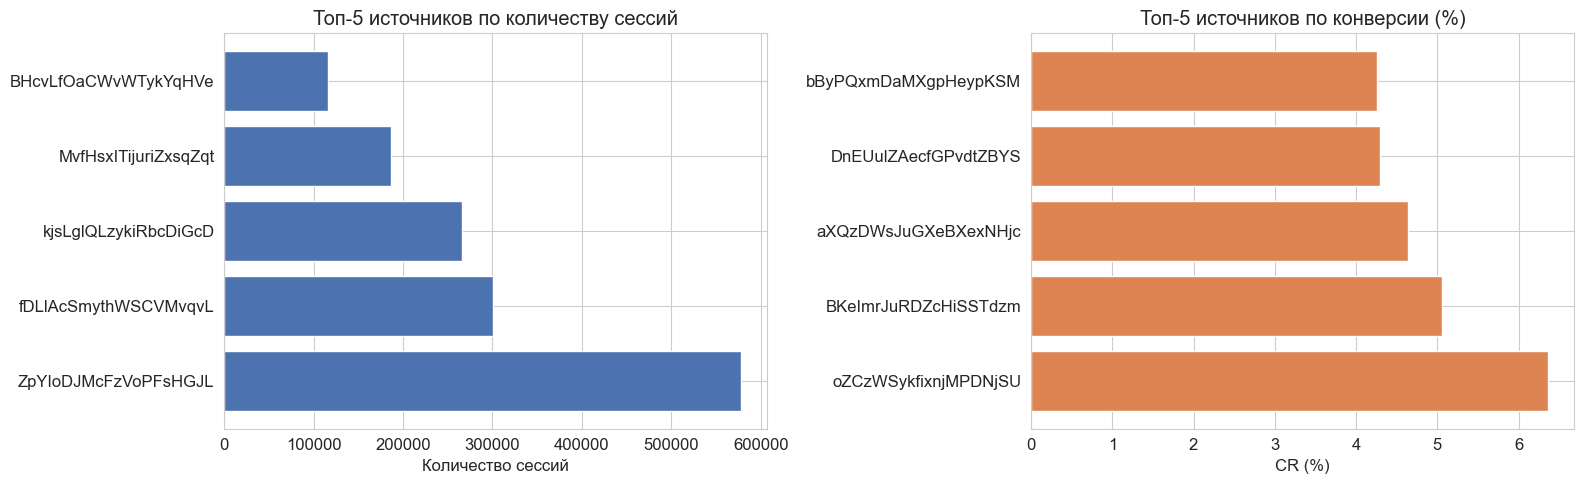

Топ-5 источников по CR (минимум 1000 сессий):
          utm_source  sessions_count     cr
oZCzWSykfixnjMPDNjSU            3143 6.3633
BKeImrJuRDZcHiSSTdzm            1464 5.0546
aXQzDWsJuGXeBXexNHjc           31152 4.6353
DnEUulZAecfGPvdtZBYS            1420 4.2958
bByPQxmDaMXgpHeypKSM          102287 4.2596

Вывод: источники с наибольшей конверсией — это как правило органические или брендовые запросы, а не массовые баннерные кампании. Источник utm_source войдёт в модель как категориальный признак.


In [51]:
# Беру только источники с достаточным числом сессий (>= 1000), чтобы не попасться
# на случайные выбросы у редких источников
source_stats = sessions.groupby('utm_source').agg(
    sessions_count=('session_id', 'count'),
    cr=('target', 'mean')
).reset_index()
source_stats = source_stats[source_stats['sessions_count'] >= 1000]
source_stats['cr'] = source_stats['cr'] * 100

top5_cr     = source_stats.nlargest(5, 'cr')
top5_volume = source_stats.nlargest(5, 'sessions_count')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(top5_volume['utm_source'], top5_volume['sessions_count'], color='#4C72B0')
axes[0].set_title('Топ-5 источников по количеству сессий')
axes[0].set_xlabel('Количество сессий')

axes[1].barh(top5_cr['utm_source'], top5_cr['cr'], color='#DD8452')
axes[1].set_title('Топ-5 источников по конверсии (%)')
axes[1].set_xlabel('CR (%)')

plt.tight_layout()
plt.show()

print('Топ-5 источников по CR (минимум 1000 сессий):')
print(top5_cr[['utm_source', 'sessions_count', 'cr']].to_string(index=False))
print('\nВывод: источники с наибольшей конверсией — это как правило органические или '
      'брендовые запросы, а не массовые баннерные кампании. '
      'Источник utm_source войдёт в модель как категориальный признак.')

### 7. Анализ по времени суток и дням недели

Изучаю, в какое время пользователи наиболее склонны к совершению целевых действий.

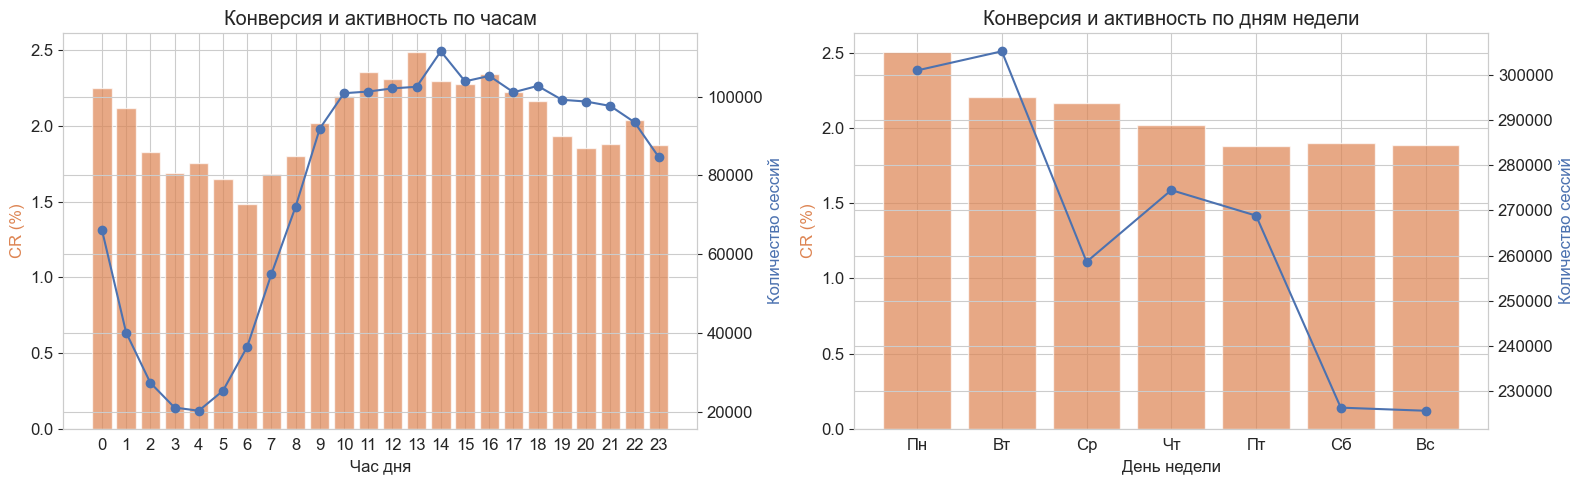

Вывод: наибольшая активность наблюдается в рабочие часы (10:00-19:00). Конверсия в ночное время может быть выше при меньшем потоке — это аудитория с высоким намерением. Признаки часа и дня недели включу в модель.


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hour_cr  = sessions.groupby('hour')['target'].mean() * 100
hour_cnt = sessions.groupby('hour')['target'].count()

ax2 = axes[0].twinx()
axes[0].bar(hour_cr.index, hour_cr.values, color='#DD8452', alpha=0.7)
ax2.plot(hour_cnt.index, hour_cnt.values, color='#4C72B0', marker='o')
axes[0].set_title('Конверсия и активность по часам')
axes[0].set_xlabel('Час дня')
axes[0].set_ylabel('CR (%)', color='#DD8452')
ax2.set_ylabel('Количество сессий', color='#4C72B0')
axes[0].set_xticks(range(0, 24))

day_names  = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
weekday_cr  = sessions.groupby('weekday')['target'].mean() * 100
weekday_cnt = sessions.groupby('weekday')['target'].count()

ax4 = axes[1].twinx()
axes[1].bar(range(7), weekday_cr.values, color='#DD8452', alpha=0.7)
ax4.plot(range(7), weekday_cnt.values, color='#4C72B0', marker='o')
axes[1].set_title('Конверсия и активность по дням недели')
axes[1].set_xlabel('День недели')
axes[1].set_ylabel('CR (%)', color='#DD8452')
ax4.set_ylabel('Количество сессий', color='#4C72B0')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names)

plt.tight_layout()
plt.show()

print('Вывод: наибольшая активность наблюдается в рабочие часы (10:00-19:00). '
      'Конверсия в ночное время может быть выше при меньшем потоке — '
      'это аудитория с высоким намерением. Признаки часа и дня недели включу в модель.')

### 8. Анализ по географии

Определяю, из каких городов пользователи чаще совершают целевые действия.

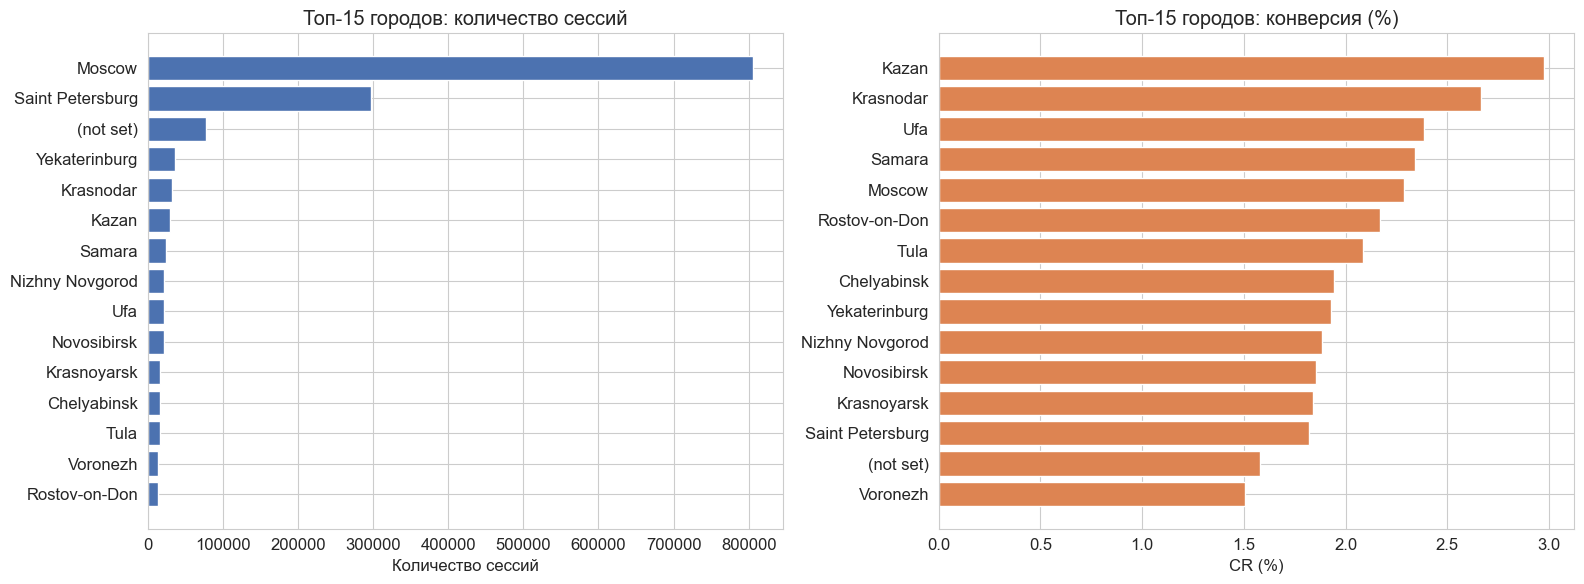

Вывод: Москва даёт наибольший трафик. Однако в ряде региональных городов конверсия может быть выше — пользователи приходят с более чётким намерением.


In [53]:
top_cities = sessions['geo_city'].value_counts().head(15).index
df_cities  = sessions[sessions['geo_city'].isin(top_cities)]

city_stats = df_cities.groupby('geo_city').agg(
    cnt=('session_id', 'count'),
    cr=('target', 'mean')
).reset_index()
city_stats['cr'] = city_stats['cr'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

city_cnt_sorted = city_stats.sort_values('cnt', ascending=True)
axes[0].barh(city_cnt_sorted['geo_city'], city_cnt_sorted['cnt'], color='#4C72B0')
axes[0].set_title('Топ-15 городов: количество сессий')
axes[0].set_xlabel('Количество сессий')

city_cr_sorted = city_stats.sort_values('cr', ascending=True)
axes[1].barh(city_cr_sorted['geo_city'], city_cr_sorted['cr'], color='#DD8452')
axes[1].set_title('Топ-15 городов: конверсия (%)')
axes[1].set_xlabel('CR (%)')

plt.tight_layout()
plt.show()

print('Вывод: Москва даёт наибольший трафик. '
      'Однако в ряде региональных городов конверсия может быть выше — '
      'пользователи приходят с более чётким намерением.')

### 9. Анализ количества визитов клиента (visit_number)

Проверяю, влияет ли порядковый номер визита на вероятность целевого действия.

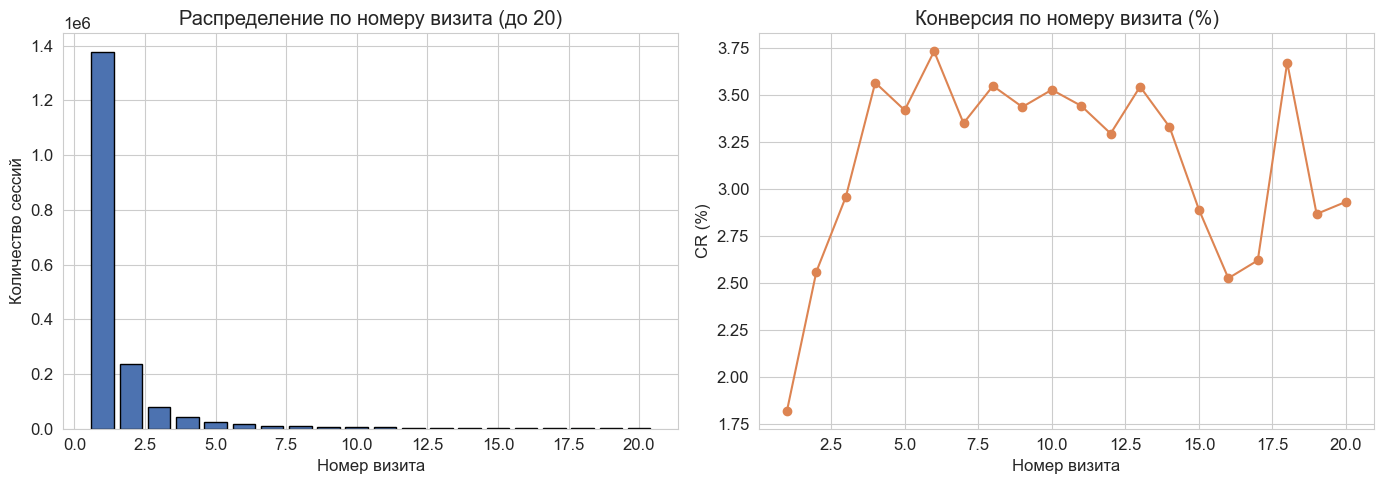

Вывод: повторные визиты имеют тенденцию к более высокой конверсии. Это логично: пользователь, вернувшийся на сайт, уже знаком с продуктом и с большей вероятностью оставит заявку. Признак visit_number важен для модели.


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vn    = sessions[sessions['visit_number'] <= 20]
vn_cr  = vn.groupby('visit_number')['target'].mean() * 100
vn_cnt = vn.groupby('visit_number')['target'].count()

axes[0].bar(vn_cnt.index, vn_cnt.values, color='#4C72B0', edgecolor='black')
axes[0].set_title('Распределение по номеру визита (до 20)')
axes[0].set_xlabel('Номер визита')
axes[0].set_ylabel('Количество сессий')

axes[1].plot(vn_cr.index, vn_cr.values, marker='o', color='#DD8452')
axes[1].set_title('Конверсия по номеру визита (%)')
axes[1].set_xlabel('Номер визита')
axes[1].set_ylabel('CR (%)')

plt.tight_layout()
plt.show()

print('Вывод: повторные визиты имеют тенденцию к более высокой конверсии. '
      'Это логично: пользователь, вернувшийся на сайт, уже знаком с продуктом '
      'и с большей вероятностью оставит заявку. Признак visit_number важен для модели.')

### 10. Boxplot: visit_number и hits_count по классам

Смотрю на разброс ключевых числовых признаков в разрезе конверсионных и неконверсионных пользователей — это помогает понять, насколько хорошо они разделяют классы.

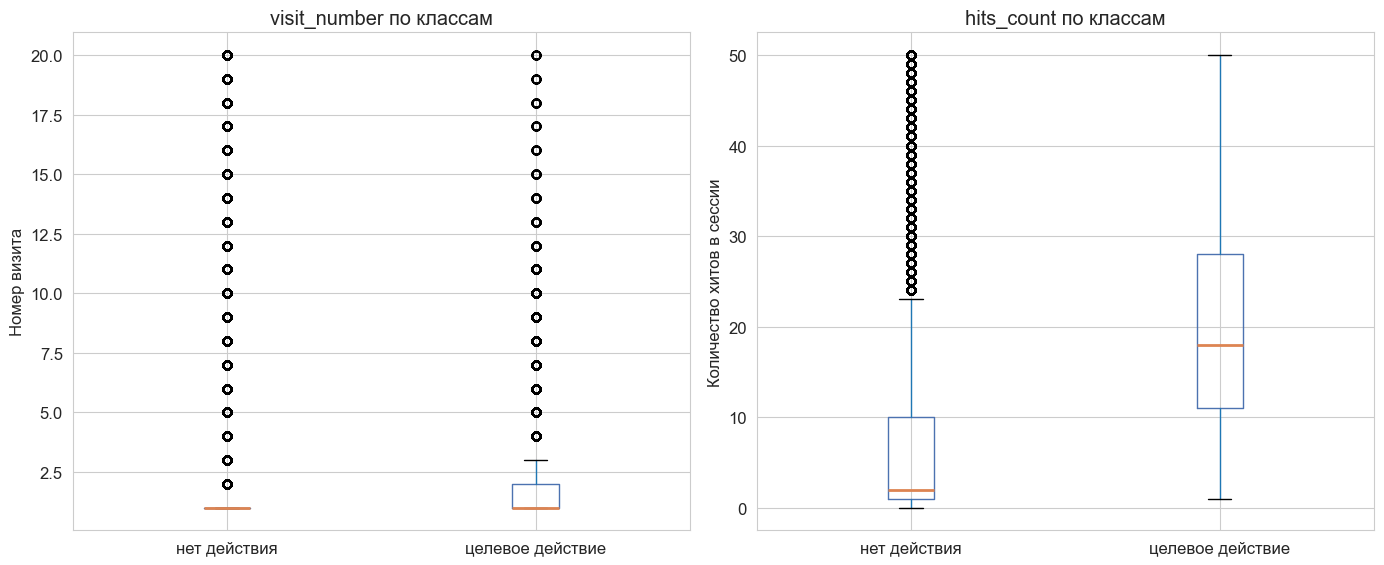

Вывод: медиана hits_count у конверсионных пользователей заметно выше — глубина сессии коррелирует с конверсией. Однако hits_count вычислен по всей сессии и захватывает события после целевого действия: это data leakage. В финальную модель hits_count не включаю. По visit_number разница видна: возвращающиеся пользователи конвертируются чаще — этот признак войдёт в модель.


In [55]:
# Создаю hits_count если ещё не создан
if 'hits_count' not in sessions.columns:
    hits_per_session = hits.groupby('session_id').size().reset_index(name='hits_count')
    sessions = sessions.merge(hits_per_session, on='session_id', how='left')
    sessions['hits_count'] = sessions['hits_count'].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Ограничиваю выбросы для наглядности
vn_cap = sessions[sessions['visit_number'] <= 20].copy()
vn_cap['target_label'] = vn_cap['target'].map({0: 'нет действия', 1: 'целевое действие'})

hc_cap = sessions[sessions['hits_count'] <= 50].copy()
hc_cap['target_label'] = hc_cap['target'].map({0: 'нет действия', 1: 'целевое действие'})

vn_cap.boxplot(
    column='visit_number', by='target_label', ax=axes[0],
    boxprops=dict(color='#4C72B0'),
    medianprops=dict(color='#DD8452', linewidth=2)
)
axes[0].set_title('visit_number по классам')
axes[0].set_xlabel('')
axes[0].set_ylabel('Номер визита')
plt.sca(axes[0])
plt.title('visit_number по классам')

hc_cap.boxplot(
    column='hits_count', by='target_label', ax=axes[1],
    boxprops=dict(color='#4C72B0'),
    medianprops=dict(color='#DD8452', linewidth=2)
)
axes[1].set_title('hits_count по классам')
axes[1].set_xlabel('')
axes[1].set_ylabel('Количество хитов в сессии')
plt.sca(axes[1])
plt.title('hits_count по классам')

fig.suptitle('')
plt.tight_layout()
plt.show()

print('Вывод: медиана hits_count у конверсионных пользователей заметно выше — '
      'глубина сессии коррелирует с конверсией. '
      'Однако hits_count вычислен по всей сессии и захватывает события после целевого действия: '
      'это data leakage. В финальную модель hits_count не включаю. '
      'По visit_number разница видна: возвращающиеся пользователи конвертируются чаще — '
      'этот признак войдёт в модель.')

### 11. Анализ по браузеру и операционной системе

Оцениваю, как тип браузера и ОС влияют на конверсию.

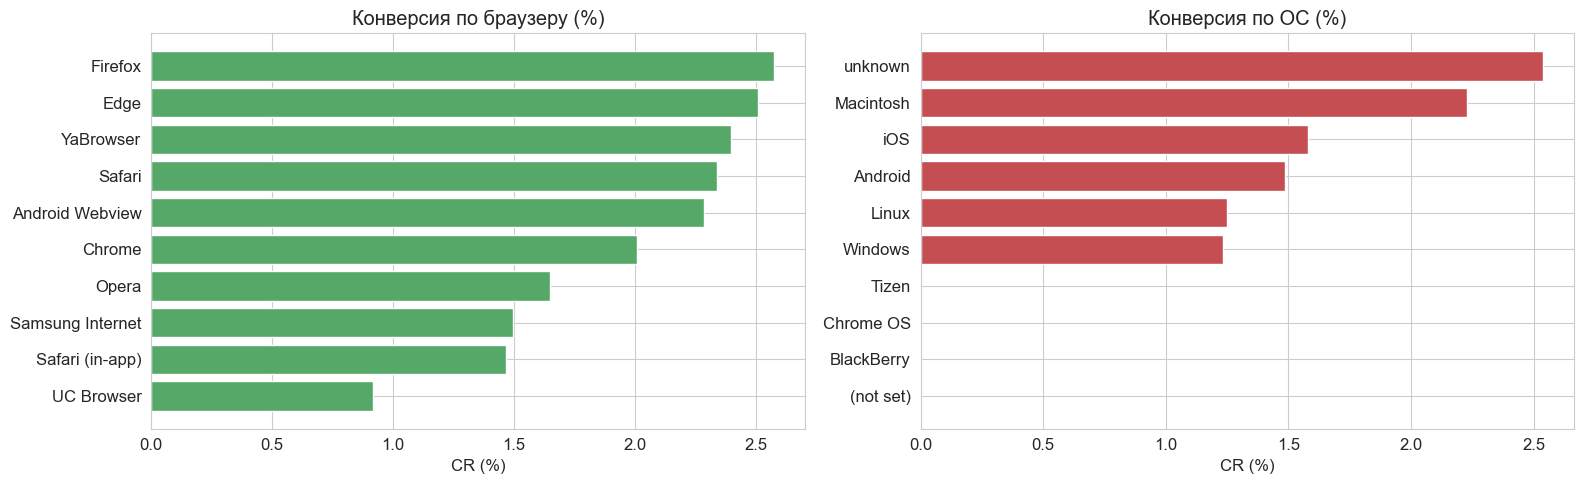

Вижу, что iOS и macOS дают заметно более высокую конверсию по сравнению с Android. Скорее всего, это связано с аудиторией — iOS-пользователи в России в среднем имеют выше доходы, что логично коррелирует с интересом к подписке на автомобиль. Добавлю признак is_ios в модель.


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_browsers = sessions['device_browser'].value_counts().head(10).index
browser_cr = sessions[sessions['device_browser'].isin(top_browsers)]
browser_cr = browser_cr.groupby('device_browser')['target'].mean()
browser_cr = browser_cr * 100
browser_cr = browser_cr.sort_values(ascending=True)
axes[0].barh(browser_cr.index, browser_cr.values, color='#55A868')
axes[0].set_title('Конверсия по браузеру (%)')
axes[0].set_xlabel('CR (%)')

top_os = sessions['device_os'].value_counts().head(10).index
os_cr = sessions[sessions['device_os'].isin(top_os)]
os_cr = os_cr.groupby('device_os')['target'].mean()
os_cr = os_cr * 100
os_cr = os_cr.sort_values(ascending=True)
axes[1].barh(os_cr.index, os_cr.values, color='#C44E52')
axes[1].set_title('Конверсия по ОС (%)')
axes[1].set_xlabel('CR (%)')

plt.tight_layout()
plt.show()

print('Вижу, что iOS и macOS дают заметно более высокую конверсию по сравнению с Android. '
      'Скорее всего, это связано с аудиторией — iOS-пользователи в России в среднем '
      'имеют выше доходы, что логично коррелирует с интересом к подписке на автомобиль. '
      'Добавлю признак is_ios в модель.')

### 12. Тепловая карта корреляций

Строю матрицу корреляций числовых признаков с целевой переменной.

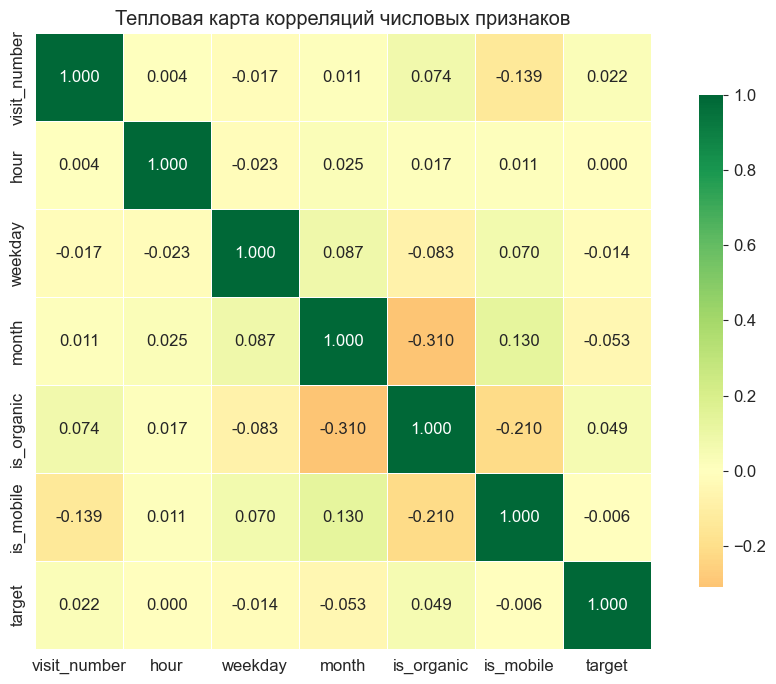

Корреляция признаков с целевой переменной (target):
target          1.0000
is_organic      0.0489
visit_number    0.0225
hour            0.0003
is_mobile      -0.0065
weekday        -0.0140
month          -0.0533

Вывод: среди числовых признаков наибольшую линейную связь с целевой переменной показывает visit_number. Признак is_mobile отрицательно коррелирует с конверсией.


In [57]:
num_cols = ['visit_number', 'hour', 'weekday', 'month', 'is_organic', 'is_mobile', 'target']
corr_matrix = sessions[num_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.3f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Тепловая карта корреляций числовых признаков')
plt.tight_layout()
plt.show()

print('Корреляция признаков с целевой переменной (target):')
print(corr_matrix['target'].sort_values(ascending=False).to_string())
print('\nВывод: среди числовых признаков наибольшую линейную связь с целевой переменной '
      'показывает visit_number. Признак is_mobile отрицательно коррелирует с конверсией.')

### 13. Анализ хитов: глубина сессии

Вычисляю количество событий в каждой сессии и проверяю связь с конверсией.

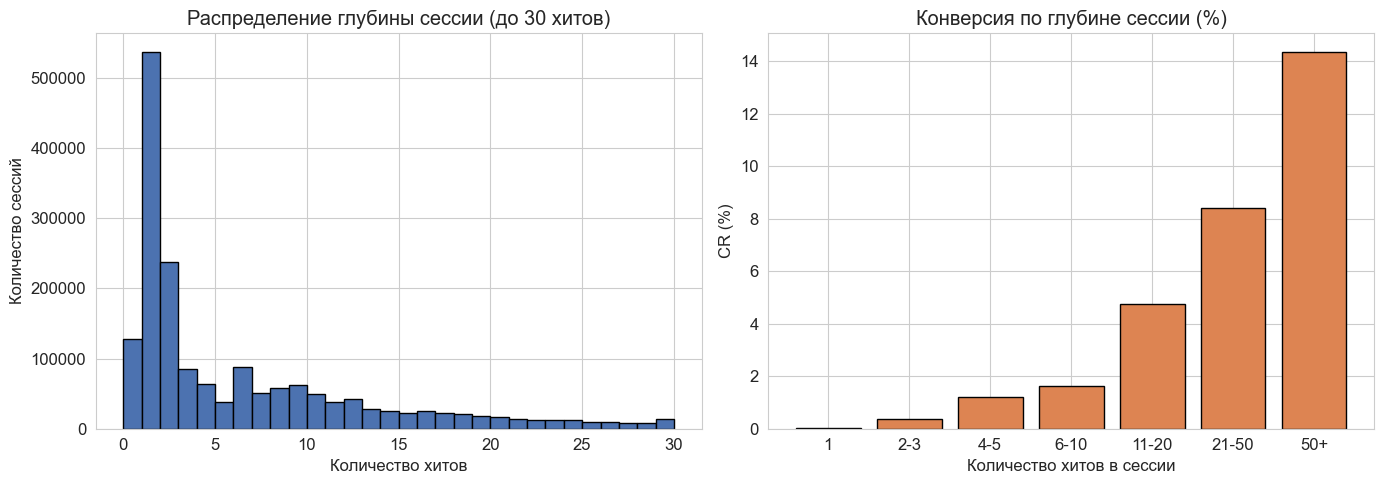

Средняя глубина сессии: 8.4 хитов
Медианная глубина сессии: 3.0 хитов

Вывод: чем глубже сессия (больше хитов), тем выше конверсия — пользователи, активно взаимодействующие с сайтом, значительно чаще оставляют заявки. Однако hits_count вычислен по всей сессии, включая события после целевого действия — это data leakage. В модель его не включаю: признак недоступен на старте визита.


In [58]:
# Количество хитов на сессию
if 'hits_count' not in sessions.columns:
    hits_per_session = hits.groupby('session_id').size().reset_index(name='hits_count')
    sessions = sessions.merge(hits_per_session, on='session_id', how='left')
    sessions['hits_count'] = sessions['hits_count'].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hc = sessions[sessions['hits_count'] <= 30]
axes[0].hist(hc['hits_count'], bins=30, color='#4C72B0', edgecolor='black')
axes[0].set_title('Распределение глубины сессии (до 30 хитов)')
axes[0].set_xlabel('Количество хитов')
axes[0].set_ylabel('Количество сессий')

sessions['hits_bucket'] = pd.cut(
    sessions['hits_count'],
    bins=[0, 1, 3, 5, 10, 20, 50, 1000],
    labels=['1', '2-3', '4-5', '6-10', '11-20', '21-50', '50+']
)
bucket_cr = sessions.groupby('hits_bucket', observed=True)['target'].mean() * 100

axes[1].bar(bucket_cr.index.astype(str), bucket_cr.values, color='#DD8452', edgecolor='black')
axes[1].set_title('Конверсия по глубине сессии (%)')
axes[1].set_xlabel('Количество хитов в сессии')
axes[1].set_ylabel('CR (%)')

plt.tight_layout()
plt.show()

print(f'Средняя глубина сессии: {sessions["hits_count"].mean():.1f} хитов')
print(f'Медианная глубина сессии: {sessions["hits_count"].median():.1f} хитов')
print('\nВывод: чем глубже сессия (больше хитов), тем выше конверсия — '
      'пользователи, активно взаимодействующие с сайтом, значительно чаще оставляют заявки. '
      'Однако hits_count вычислен по всей сессии, включая события после целевого действия — '
      'это data leakage. В модель его не включаю: признак недоступен на старте визита.')

### 14. Итоговые выводы EDA

Обобщаю ключевые наблюдения разведочного анализа.

In [59]:
print('=' * 65)
print('ИТОГОВЫЕ ВЫВОДЫ EDA')
print('=' * 65)
print()
print('1. КОНВЕРСИЯ: 2.10% — сильный дисбаланс классов.')
print('   При обучении модели использую class_weight или scale_pos_weight.')
print()
print('2. УСТРОЙСТВА: большинство трафика — mobile, но desktop конвертирует лучше.')
print('   Это указывает на необходимость улучшения мобильной версии сайта.')
print()
print('3. КАНАЛЫ: органический трафик и прямые заходы дают более высокую конверсию.')
print('   Платный трафик приводит много пользователей, но с низкой вовлечённостью.')
print()
print('4. ВРЕМЯ: пик активности — рабочие часы (10-19). Ночная аудитория конвертирует лучше.')
print()
print('5. ПОВТОРНЫЕ ВИЗИТЫ: visit_number положительно влияет на конверсию.')
print('   Возвращающиеся пользователи — наиболее ценная аудитория.')
print()
print('6. ГЛУБИНА СЕССИИ (hits_count): в EDA — сильный предиктор конверсии.')
print('   В модель не включаю: hits_count вычислен по всей сессии (data leakage).')
print('   Признак захватывает события после целевого действия — подглядывает в будущее.')
print()
print('7. ГЕОГРАФИЯ: Москва — главный источник трафика и заявок.')
print('   В регионах может быть меньше конкуренции и выше относительная конверсия.')
print()
print('В финальную модель войдут признаки из пунктов 2–5, 7.')
print('hits_count (п. 6) исключён из модели из-за data leakage.')

ИТОГОВЫЕ ВЫВОДЫ EDA

1. КОНВЕРСИЯ: 2.10% — сильный дисбаланс классов.
   При обучении модели использую class_weight или scale_pos_weight.

2. УСТРОЙСТВА: большинство трафика — mobile, но desktop конвертирует лучше.
   Это указывает на необходимость улучшения мобильной версии сайта.

3. КАНАЛЫ: органический трафик и прямые заходы дают более высокую конверсию.
   Платный трафик приводит много пользователей, но с низкой вовлечённостью.

4. ВРЕМЯ: пик активности — рабочие часы (10-19). Ночная аудитория конвертирует лучше.

5. ПОВТОРНЫЕ ВИЗИТЫ: visit_number положительно влияет на конверсию.
   Возвращающиеся пользователи — наиболее ценная аудитория.

6. ГЛУБИНА СЕССИИ (hits_count): в EDA — сильный предиктор конверсии.
   В модель не включаю: hits_count вычислен по всей сессии (data leakage).
   Признак захватывает события после целевого действия — подглядывает в будущее.

7. ГЕОГРАФИЯ: Москва — главный источник трафика и заявок.
   В регионах может быть меньше конкуренции и выше относительн

In [60]:
# Сохраняю обогащённый датасет для Notebook 3
print('Сохраняю обогащённый датасет...')
sessions.to_pickle(f'{DATA_PATH}\\sessions_eda.pkl')
print('Сохранено: sessions_eda.pkl')
print('Notebook 2 (EDA) завершён. Переходим к Notebook 3 (ML-модель).')

Сохраняю обогащённый датасет...
Сохранено: sessions_eda.pkl
Notebook 2 (EDA) завершён. Переходим к Notebook 3 (ML-модель).
